# EvidenceLab #06: Exploratory Data Analysis
## The pattern I almost dismissed
**Cleaning is only the beginning. Ask what the data can tell you before fitting a model.**

Dr. Amobi Andrew Onovo · See it. Understand it. Run it.

Select **Runtime → Run all**, then read from top to bottom. The teaching CSV downloads automatically and is checked against its published SHA-256. No upload, API key or path entry is required. This notebook produces an audit, exploratory charts, adjusted odds ratios and reproducible exports under `outputs/`.

**By the end:** investigate unusual values, distinguish inference from prediction, and use EDA to justify model choices.

### Your learning route
Understand → calculate → visualize → audit → engineer → connect → model → experiment → interpret.

## A quick win: accuracy can hide a missed outcome
In a deliberately simplified teaching example, 15 of 100 people have the recorded 10-year CHD outcome. These counts illustrate the logic; the real teaching dataset follows below.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json, hashlib, io, urllib.request
OUT = Path('outputs'); OUT.mkdir(exist_ok=True)
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 15, 'figure.dpi': 110})
print('Predict no CHD for all 100: accuracy = 85/100 = 85%; sensitivity = 0/15 = 0%.')


Predict no CHD for all 100: accuracy = 85/100 = 85%; sensitivity = 0/15 = 0%.


The majority-class prediction looks accurate while missing every outcome. Unequal classes alone do not select a balancing method; the analytical objective does.


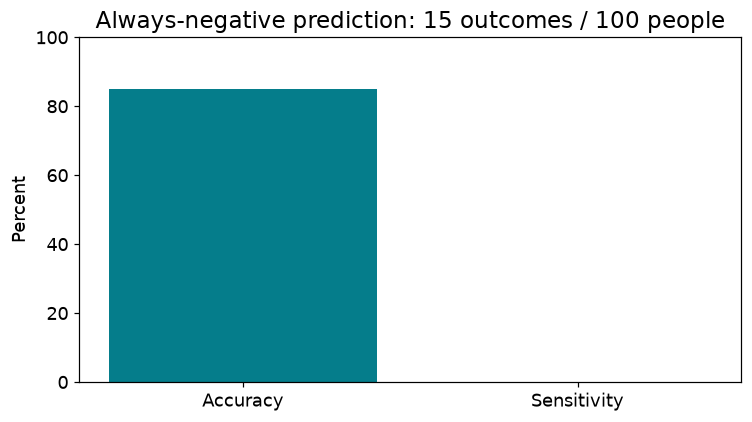

In [2]:
plt.figure(figsize=(7,4))
plt.bar(['Accuracy', 'Sensitivity'], [85, 0], color=['#057D8B','#DB5461'])
plt.ylim(0,100); plt.ylabel('Percent'); plt.title('Always-negative prediction: 15 outcomes / 100 people')
plt.tight_layout(); plt.savefig(OUT/'00_accuracy_trap.png'); plt.show()


## The Framingham teaching copy
This is a cardiovascular-risk teaching CSV, not the complete original Framingham Heart Study. It contains 4,240 rows and 16 columns. The owner-supplied CSV is already published with Lesson 02; its source and rights are documented there. It is not relicensed here.

The target is the recorded binary `TenYearCHD` outcome. We study observed and adjusted associations, not causal effects. Age is in years; blood pressure is in mmHg; cigarettes/day is a count. Glucose and cholesterol are described in dataset units because the supplied CSV lacks a measurement codebook.


In [3]:
# Core packages
import warnings
warnings.filterwarnings("default")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    classification_report
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


## 1. Load the dataset

For Google Colab, upload your Framingham CSV when prompted.

The notebook does not modify the original file. All transformations are created in memory on a copy.


In [4]:
DATA_SHA = '412c9ea5f0dfb7ad243dfcd1f2b4df500101904a8f443a22f3080394391853e9'
DATA_URL = 'https://raw.githubusercontent.com/amobionovo/EvidenceLab/f2dd06bab1378ffa52a5735e2e97c685e5d34a4c/lessons/02-missing-data/data/framingham.csv'
local = Path('framingham.csv')
raw = local.read_bytes() if local.exists() else urllib.request.urlopen(DATA_URL, timeout=60).read()
assert hashlib.sha256(raw).hexdigest() == DATA_SHA, 'Dataset hash differs from the verified teaching copy.'
df_raw = pd.read_csv(io.BytesIO(raw)); df = df_raw.copy()
assert df.shape == (4240,16)
assert df['TenYearCHD'].notna().all() and set(df['TenYearCHD'].unique()) == {0,1}
print(f'Verified teaching data: {len(df):,} rows; {df.shape[1]} variables')
df.head()


Verified teaching data: 4,240 rows; 16 variables


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.000,0,0.000,0.000,0,0,0,195.000,106.000,70.000,26.970,80.000,77.000,0
1,0,46,2.000,0,0.000,0.000,0,0,0,250.000,121.000,81.000,28.730,95.000,76.000,0
2,1,48,1.000,1,20.000,0.000,0,0,0,245.000,127.500,80.000,25.340,75.000,70.000,0
3,0,61,3.000,1,30.000,0.000,0,1,0,225.000,150.000,95.000,28.580,65.000,103.000,1
4,0,46,3.000,1,23.000,0.000,0,0,0,285.000,130.000,84.000,23.100,85.000,85.000,0


## 2. QUESTION

Before touching an algorithm, define the analytical question.

> **What demographic, behavioral, metabolic, and cardiovascular patterns distinguish participants who develop coronary heart disease within 10 years from those who do not?**

The outcome in this dataset is `TenYearCHD`, coded 1 for a recorded 10-year CHD outcome and 0 otherwise.

This lesson uses the model for **association and interpretation**, not causal inference.


In [5]:
outcome_counts = df["TenYearCHD"].value_counts().sort_index()
outcome_pct = df["TenYearCHD"].value_counts(normalize=True).sort_index() * 100

outcome_summary = pd.DataFrame({
    "n": outcome_counts,
    "percent": outcome_pct
})
outcome_summary.index = ["No 10-year CHD", "10-year CHD"]
outcome_summary


,n,percent
No 10-year CHD,3596,84.811
10-year CHD,644,15.189


In [6]:
chd_prevalence = df["TenYearCHD"].mean()
majority_accuracy = max(chd_prevalence, 1 - chd_prevalence)

print(f"Observed 10-year CHD prevalence: {chd_prevalence:.1%}")
print(f"Accuracy from predicting the majority class for everyone: {majority_accuracy:.1%}")
print()
print("Teaching point: accuracy alone would be misleading for a predictive model.")


Observed 10-year CHD prevalence: 15.2%
Accuracy from predicting the majority class for everyone: 84.8%

Teaching point: accuracy alone would be misleading for a predictive model.


## 3. AUDIT

A rigorous audit asks:

- What is missing?
- What is duplicated?
- What is impossible?
- What is unusual?
- What is inconsistent?

Do not begin by deleting observations. First understand what you are seeing.

**CHECK → CLEAN → VERIFY → ANALYZE.** We begin with checks, preserve raw values and document every repair before interpreting associations.


In [7]:
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_n": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100,
    "unique_n": df.nunique(dropna=True)
}).sort_values("missing_pct", ascending=False)

audit


,dtype,missing_n,missing_pct,unique_n
glucose,float64,388,9.151,143
education,float64,105,2.476,4
BPMeds,float64,53,1.250,2
totChol,float64,50,1.179,248
cigsPerDay,float64,29,0.684,33
BMI,float64,19,0.448,1364
heartRate,float64,1,0.024,73
male,int64,0,0.000,2
prevalentHyp,int64,0,0.000,2
prevalentStroke,int64,0,0.000,2


In [8]:
print("Exact duplicate rows:", df.duplicated().sum())

numeric_cols = df.select_dtypes(include=np.number).columns
negative_counts = (df[numeric_cols] < 0).sum()
negative_counts = negative_counts[negative_counts > 0]

if negative_counts.empty:
    print("Negative numeric values: none detected")
else:
    print("Negative numeric values detected:")
    print(negative_counts)


Exact duplicate rows: 0
Negative numeric values: none detected


### Missingness is not just a percentage

A missing-data percentage tells us **how much** is missing, not **why** it is missing.

For publication-grade inference, the missingness mechanism should be considered before choosing complete-case analysis, single imputation, or multiple imputation.


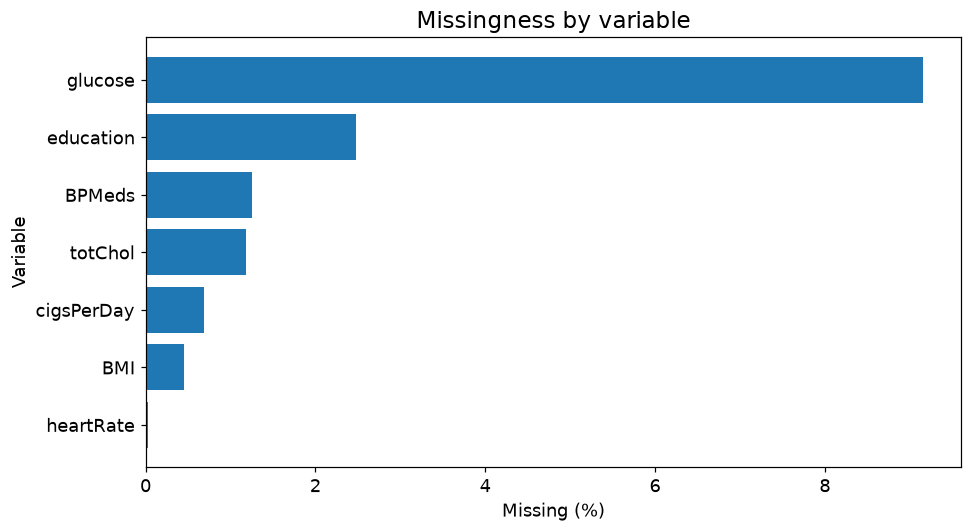

In [9]:
missing_plot = audit.loc[audit["missing_n"] > 0, "missing_pct"].sort_values()

plt.figure(figsize=(9, 5))
plt.barh(missing_plot.index, missing_plot.values)
plt.xlabel("Missing (%)")
plt.ylabel("Variable")
plt.title("Missingness by variable")
plt.tight_layout()
plt.savefig(OUT/'chart_11.png', bbox_inches='tight'); plt.show()


## 4. TYPE

Variable type determines which summaries, plots, transformations, and statistical models are appropriate.

For this lesson:

- **Binary categorical:** male, currentSmoker, BPMeds, prevalentStroke, prevalentHyp, diabetes, TenYearCHD
- **Ordinal categorical:** education
- **Count:** cigsPerDay
- **Continuous:** age, totChol, sysBP, diaBP, BMI, heartRate, glucose

Continuous/discrete describe variable forms. Nominal/ordinal describe categorical structure. Interval/ratio describe measurement scales. These concepts should not be treated as interchangeable.


In [10]:
variable_roles = {
    "male": "Binary categorical",
    "age": "Continuous",
    "education": "Ordinal categorical",
    "currentSmoker": "Binary categorical",
    "cigsPerDay": "Count",
    "BPMeds": "Binary categorical",
    "prevalentStroke": "Binary categorical",
    "prevalentHyp": "Binary categorical",
    "diabetes": "Binary categorical",
    "totChol": "Continuous",
    "sysBP": "Continuous",
    "diaBP": "Continuous",
    "BMI": "Continuous",
    "heartRate": "Continuous",
    "glucose": "Continuous",
    "TenYearCHD": "Binary outcome"
}

pd.DataFrame(
    {"variable": list(variable_roles.keys()), "role": list(variable_roles.values())}
)


,variable,role
0,male,Binary categorical
1,age,Continuous
2,education,Ordinal categorical
3,currentSmoker,Binary categorical
4,cigsPerDay,Count
5,BPMeds,Binary categorical
6,prevalentStroke,Binary categorical
7,prevalentHyp,Binary categorical
8,diabetes,Binary categorical
9,totChol,Continuous


## 5. REPAIR

### Outliers: flag, verify, understand, decide

The 1.5 × IQR rule is useful for **flagging** unusual observations. It is not an automatic deletion rule.

In clinical data, an extreme blood pressure or glucose value may be unusual and clinically important at the same time.


In [11]:
continuous = ["age", "totChol", "sysBP", "diaBP", "BMI", "heartRate", "glucose"]

def iqr_outlier_summary(data, columns):
    rows = []
    for col in columns:
        s = data[col].dropna()
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        low = q1 - 1.5 * iqr
        high = q3 + 1.5 * iqr
        n_flagged = ((s < low) | (s > high)).sum()
        rows.append({
            "variable": col,
            "Q1": q1,
            "Q3": q3,
            "lower_fence": low,
            "upper_fence": high,
            "flagged_n": int(n_flagged),
            "flagged_pct": 100 * n_flagged / len(s)
        })
    return pd.DataFrame(rows).sort_values("flagged_n", ascending=False)

outlier_summary = iqr_outlier_summary(df, continuous)
outlier_summary


,variable,Q1,Q3,lower_fence,upper_fence,flagged_n,flagged_pct
6,glucose,71.000,87.000,47.000,111.000,188,4.881
2,sysBP,117.000,144.000,76.500,184.500,126,2.972
4,BMI,23.070,28.040,15.615,35.495,97,2.298
3,diaBP,75.000,90.000,52.500,112.500,77,1.816
5,heartRate,68.000,83.000,45.500,105.500,76,1.793
1,totChol,206.000,263.000,120.500,348.500,56,1.337
0,age,42.000,56.000,21.000,77.000,0,0.000


<temporary kernel>/573548668.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["sysBP"].dropna(), vert=False)


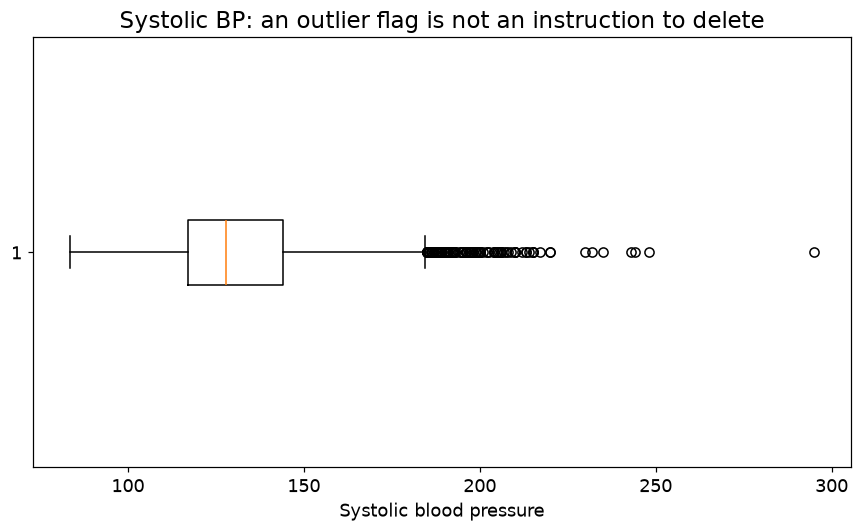

In [12]:
plt.figure(figsize=(8, 5))
plt.boxplot(df["sysBP"].dropna(), vert=False)
plt.xlabel("Systolic blood pressure")
plt.title("Systolic BP: an outlier flag is not an instruction to delete")
plt.tight_layout()
plt.savefig(OUT/'chart_16.png', bbox_inches='tight'); plt.show()


## 6. ENGINEER

Feature engineering should make variables more informative or clinically interpretable.

We will create several **exploratory** features while preserving the original columns.

- Pulse pressure = systolic BP - diastolic BP
- Mean arterial pressure ≈ DBP + 1/3(SBP - DBP)
- Age bands for visualization
- Smoking-intensity groups for visualization
- BMI categories for visualization

For regression, continuous variables are usually retained as continuous unless there is a clear reason to categorize them.


In [13]:
df_eda = df.copy()

df_eda["pulse_pressure"] = df_eda["sysBP"] - df_eda["diaBP"]
df_eda["mean_arterial_pressure"] = (
    df_eda["diaBP"] + (df_eda["sysBP"] - df_eda["diaBP"]) / 3
)

df_eda["age_band"] = pd.cut(
    df_eda["age"],
    bins=[29, 39, 49, 59, np.inf],
    labels=["30s", "40s", "50s", "60+"]
)

df_eda["smoking_intensity"] = pd.cut(
    df_eda["cigsPerDay"],
    bins=[-0.1, 0, 10, 20, np.inf],
    labels=["0", "1-10", "11-20", ">20"]
)

df_eda["BMI_category"] = pd.cut(
    df_eda["BMI"],
    bins=[0, 18.5, 25, 30, np.inf],
    labels=["Underweight", "Normal", "Overweight", "Obesity"],
    right=False
)

df_eda[
    ["pulse_pressure", "mean_arterial_pressure", "age_band",
     "smoking_intensity", "BMI_category"]
].head()


,pulse_pressure,mean_arterial_pressure,age_band,smoking_intensity,BMI_category
0,36.000,82.000,30s,0,Overweight
1,40.000,94.333,40s,0,Overweight
2,47.500,95.833,40s,11-20,Overweight
3,55.000,113.333,60+,>20,Overweight
4,46.000,99.333,40s,>20,Normal


Missing cigarettes/day remains missing in smoking groups. These categories summarize the data for exploration; the regression retains continuous smoking intensity.

## 7. EXPLORE: univariate distributions

Univariate EDA asks what each variable looks like before considering the outcome.

Look at:

- center
- spread
- skewness
- tails
- unusual values
- plausible ranges


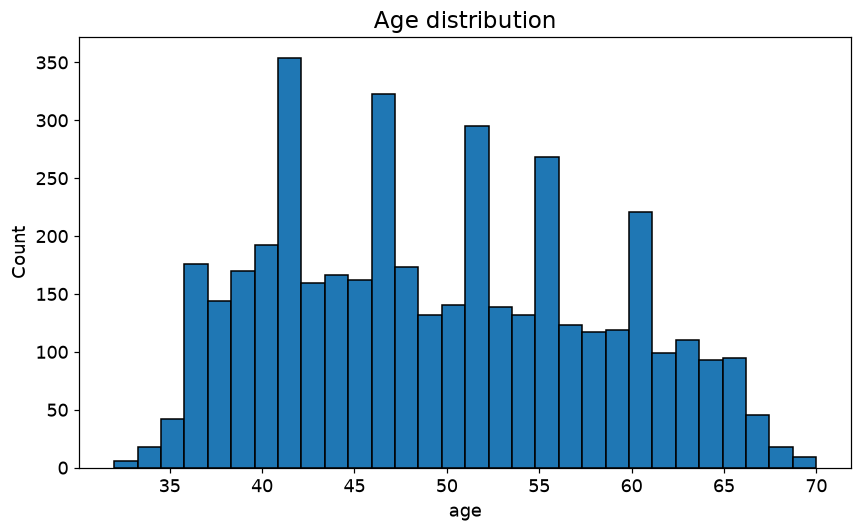

In [14]:
plt.figure(figsize=(8, 5))
plt.hist(df_eda["age"].dropna(), bins=30, edgecolor="black")
plt.xlabel("age")
plt.ylabel("Count")
plt.title("Age distribution")
plt.tight_layout()
plt.savefig(OUT/'chart_20.png', bbox_inches='tight'); plt.show()


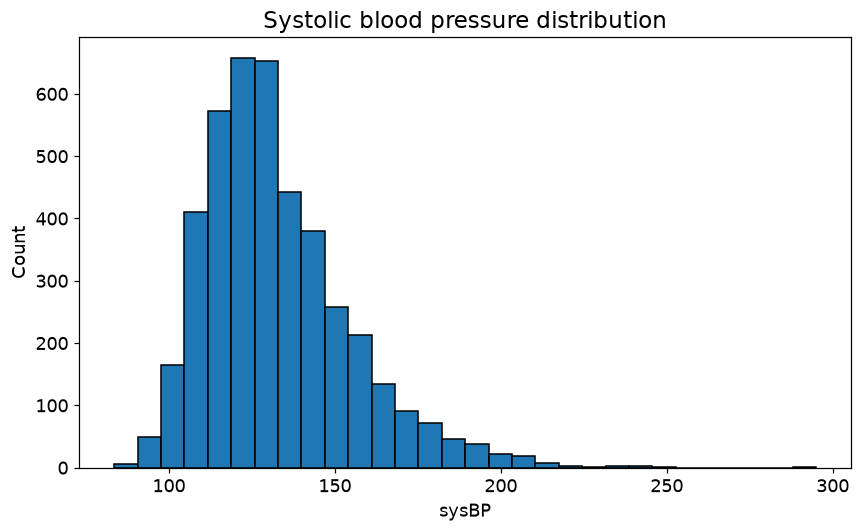

In [15]:
plt.figure(figsize=(8, 5))
plt.hist(df_eda["sysBP"].dropna(), bins=30, edgecolor="black")
plt.xlabel("sysBP")
plt.ylabel("Count")
plt.title("Systolic blood pressure distribution")
plt.tight_layout()
plt.savefig(OUT/'chart_21.png', bbox_inches='tight'); plt.show()


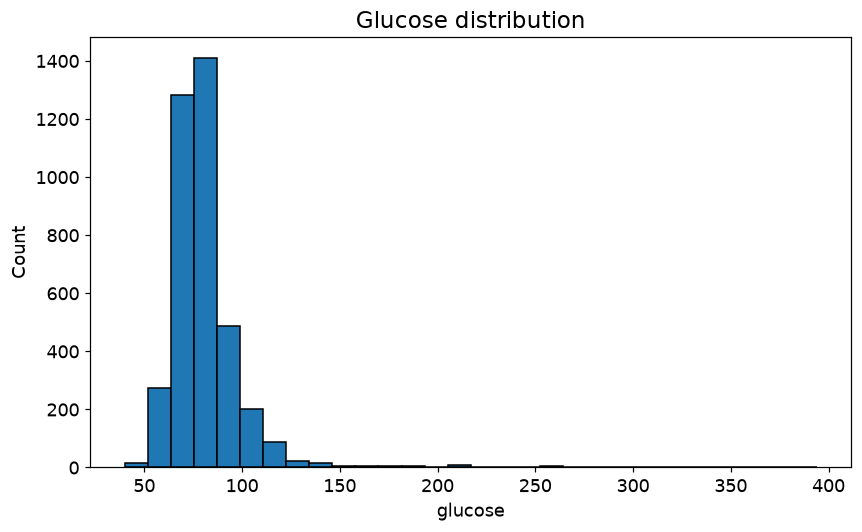

In [16]:
plt.figure(figsize=(8, 5))
plt.hist(df_eda["glucose"].dropna(), bins=30, edgecolor="black")
plt.xlabel("glucose")
plt.ylabel("Count")
plt.title("Glucose distribution")
plt.tight_layout()
plt.savefig(OUT/'chart_22.png', bbox_inches='tight'); plt.show()


## 8. CONNECT: bivariate relationships with the outcome

Now ask whether variables behave differently among participants with and without 10-year CHD.

These are **unadjusted associations**. They do not establish causality.


In [17]:
continuous_by_outcome = (
    df_eda.groupby("TenYearCHD")[["age", "sysBP", "diaBP", "BMI", "glucose", "totChol"]]
    .agg(["mean", "median", "std"])
)

continuous_by_outcome


age                sysBP                 diaBP                \
             mean median   std    mean  median    std   mean median    std   
TenYearCHD                                                                   
0          48.763 48.000 8.414 130.337 127.000 20.450 82.166 81.000 11.338   
1          54.146 55.000 8.006 143.619 139.000 26.690 86.981 85.500 14.027   

              BMI              glucose               totChol                 
             mean median   std    mean median    std    mean  median    std  
TenYearCHD                                                                   
0          25.672 25.250 3.983  80.679 78.000 18.963 235.147 232.000 43.766  
1          26.531 26.155 4.522  89.008 79.000 41.141 245.389 241.000 48.076

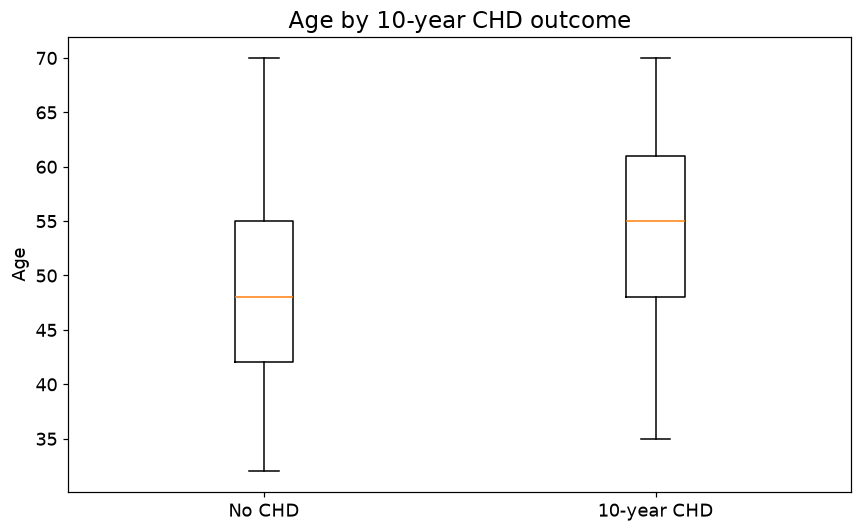

In [18]:
group0 = df_eda.loc[df_eda["TenYearCHD"] == 0, "age"].dropna()
group1 = df_eda.loc[df_eda["TenYearCHD"] == 1, "age"].dropna()

plt.figure(figsize=(8, 5))
plt.boxplot([group0, group1], tick_labels=["No CHD", "10-year CHD"])
plt.ylabel("Age")
plt.title("Age by 10-year CHD outcome")
plt.tight_layout()
plt.savefig(OUT/'chart_25.png', bbox_inches='tight'); plt.show()


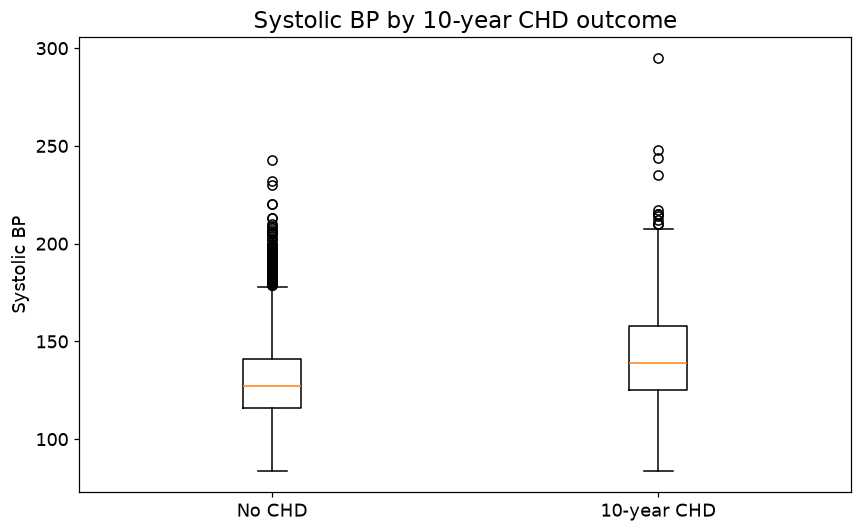

In [19]:
group0 = df_eda.loc[df_eda["TenYearCHD"] == 0, "sysBP"].dropna()
group1 = df_eda.loc[df_eda["TenYearCHD"] == 1, "sysBP"].dropna()

plt.figure(figsize=(8, 5))
plt.boxplot([group0, group1], tick_labels=["No CHD", "10-year CHD"])
plt.ylabel("Systolic BP")
plt.title("Systolic BP by 10-year CHD outcome")
plt.tight_layout()
plt.savefig(OUT/'chart_26.png', bbox_inches='tight'); plt.show()


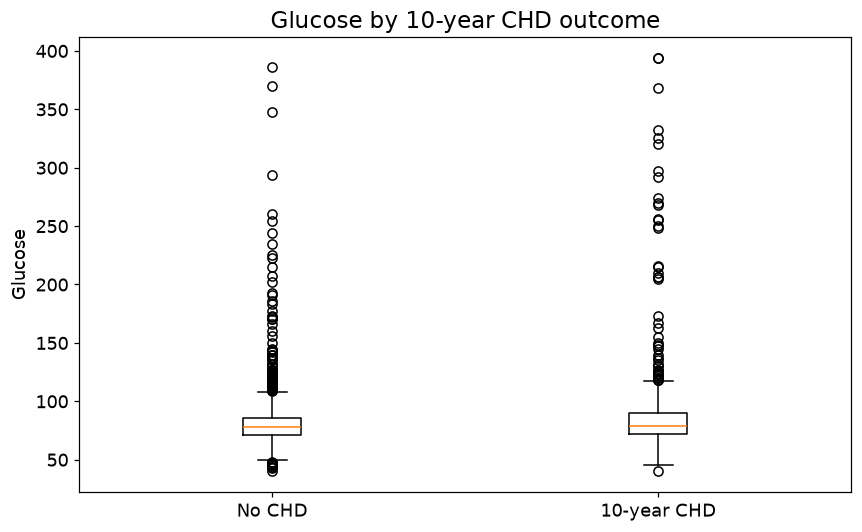

In [20]:
group0 = df_eda.loc[df_eda["TenYearCHD"] == 0, "glucose"].dropna()
group1 = df_eda.loc[df_eda["TenYearCHD"] == 1, "glucose"].dropna()

plt.figure(figsize=(8, 5))
plt.boxplot([group0, group1], tick_labels=["No CHD", "10-year CHD"])
plt.ylabel("Glucose")
plt.title("Glucose by 10-year CHD outcome")
plt.tight_layout()
plt.savefig(OUT/'chart_27.png', bbox_inches='tight'); plt.show()


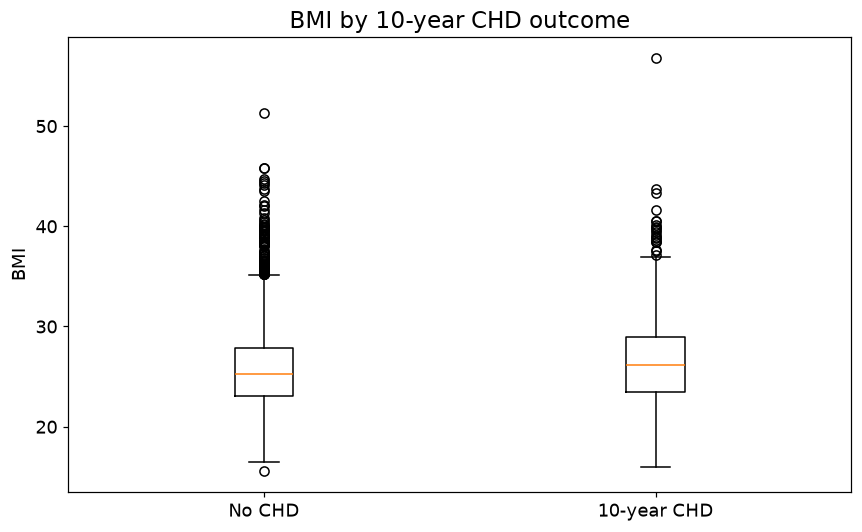

In [21]:
group0 = df_eda.loc[df_eda["TenYearCHD"] == 0, "BMI"].dropna()
group1 = df_eda.loc[df_eda["TenYearCHD"] == 1, "BMI"].dropna()

plt.figure(figsize=(8, 5))
plt.boxplot([group0, group1], tick_labels=["No CHD", "10-year CHD"])
plt.ylabel("BMI")
plt.title("BMI by 10-year CHD outcome")
plt.tight_layout()
plt.savefig(OUT/'chart_28.png', bbox_inches='tight'); plt.show()


### Categorical predictors: compare observed CHD prevalence

A risk or prevalence plot is often more interpretable than comparing raw counts when group sizes differ.


In [22]:
binary_predictors = [
    "male", "currentSmoker", "BPMeds",
    "prevalentStroke", "prevalentHyp", "diabetes"
]

risk_rows = []
for col in binary_predictors:
    tmp = (
        df_eda.groupby(col)["TenYearCHD"]
        .agg(["count", "mean"])
        .reset_index()
        .rename(columns={"mean": "CHD_prevalence"})
    )
    tmp["variable"] = col
    risk_rows.append(tmp)

risk_table = pd.concat(risk_rows, ignore_index=True)
risk_table["CHD_prevalence_pct"] = risk_table["CHD_prevalence"] * 100
risk_table[["variable"] + [c for c in risk_table.columns if c != "variable"]]


,variable,male,count,CHD_prevalence,currentSmoker,BPMeds,prevalentStroke,prevalentHyp,diabetes,CHD_prevalence_pct
0,male,0.000,2420,0.124,NaN,NaN,NaN,NaN,NaN,12.438
1,male,1.000,1820,0.188,NaN,NaN,NaN,NaN,NaN,18.846
2,currentSmoker,NaN,2145,0.145,0.000,NaN,NaN,NaN,NaN,14.499
3,currentSmoker,NaN,2095,0.159,1.000,NaN,NaN,NaN,NaN,15.895
4,BPMeds,NaN,4063,0.146,NaN,0.000,NaN,NaN,NaN,14.571
5,BPMeds,NaN,124,0.331,NaN,1.000,NaN,NaN,NaN,33.065
6,prevalentStroke,NaN,4215,0.150,NaN,NaN,0.000,NaN,NaN,15.018
7,prevalentStroke,NaN,25,0.440,NaN,NaN,1.000,NaN,NaN,44.000
8,prevalentHyp,NaN,2923,0.109,NaN,NaN,NaN,0.000,NaN,10.913
9,prevalentHyp,NaN,1317,0.247,NaN,NaN,NaN,1.000,NaN,24.677


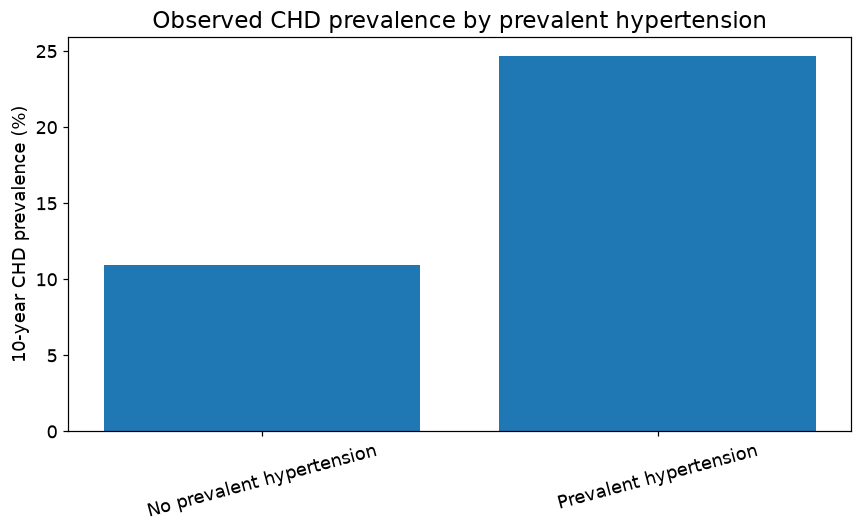

In [23]:
hyp_risk = (
    df_eda.groupby("prevalentHyp")["TenYearCHD"]
    .mean()
    .rename(index={0: "No prevalent hypertension", 1: "Prevalent hypertension"})
    * 100
)

plt.figure(figsize=(8, 5))
plt.bar(hyp_risk.index, hyp_risk.values)
plt.ylabel("10-year CHD prevalence (%)")
plt.title("Observed CHD prevalence by prevalent hypertension")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(OUT/'chart_31.png', bbox_inches='tight'); plt.show()


## 9. CONNECT: relationships among predictors

EDA also tells us whether predictors are carrying overlapping information.

Examples worth checking in this dataset include:

- current smoking status vs cigarettes per day
- systolic vs diastolic BP
- systolic BP vs prevalent hypertension
- glucose vs diabetes

High correlation does not automatically mean one variable must be removed, but it should trigger scientific and statistical review before model specification.


In [24]:
corr_vars = [
    "currentSmoker", "cigsPerDay", "sysBP", "diaBP",
    "prevalentHyp", "glucose", "diabetes", "age",
    "totChol", "BMI", "heartRate"
]

corr = df_eda[corr_vars].corr()
corr.round(2)


,currentSmoker,cigsPerDay,sysBP,diaBP,prevalentHyp,glucose,diabetes,age,totChol,BMI,heartRate
currentSmoker,1.000,0.770,-0.130,-0.110,-0.100,-0.060,-0.040,-0.210,-0.050,-0.170,0.060
cigsPerDay,0.770,1.000,-0.090,-0.060,-0.070,-0.060,-0.040,-0.190,-0.030,-0.090,0.080
sysBP,-0.130,-0.090,1.000,0.780,0.700,0.140,0.110,0.390,0.210,0.330,0.180
diaBP,-0.110,-0.060,0.780,1.000,0.620,0.060,0.050,0.210,0.160,0.380,0.180
prevalentHyp,-0.100,-0.070,0.700,0.620,1.000,0.090,0.080,0.310,0.160,0.300,0.150
glucose,-0.060,-0.060,0.140,0.060,0.090,1.000,0.620,0.120,0.050,0.090,0.090
diabetes,-0.040,-0.040,0.110,0.050,0.080,0.620,1.000,0.100,0.040,0.090,0.050
age,-0.210,-0.190,0.390,0.210,0.310,0.120,0.100,1.000,0.260,0.140,-0.010
totChol,-0.050,-0.030,0.210,0.160,0.160,0.050,0.040,0.260,1.000,0.120,0.090
BMI,-0.170,-0.090,0.330,0.380,0.300,0.090,0.090,0.140,0.120,1.000,0.070


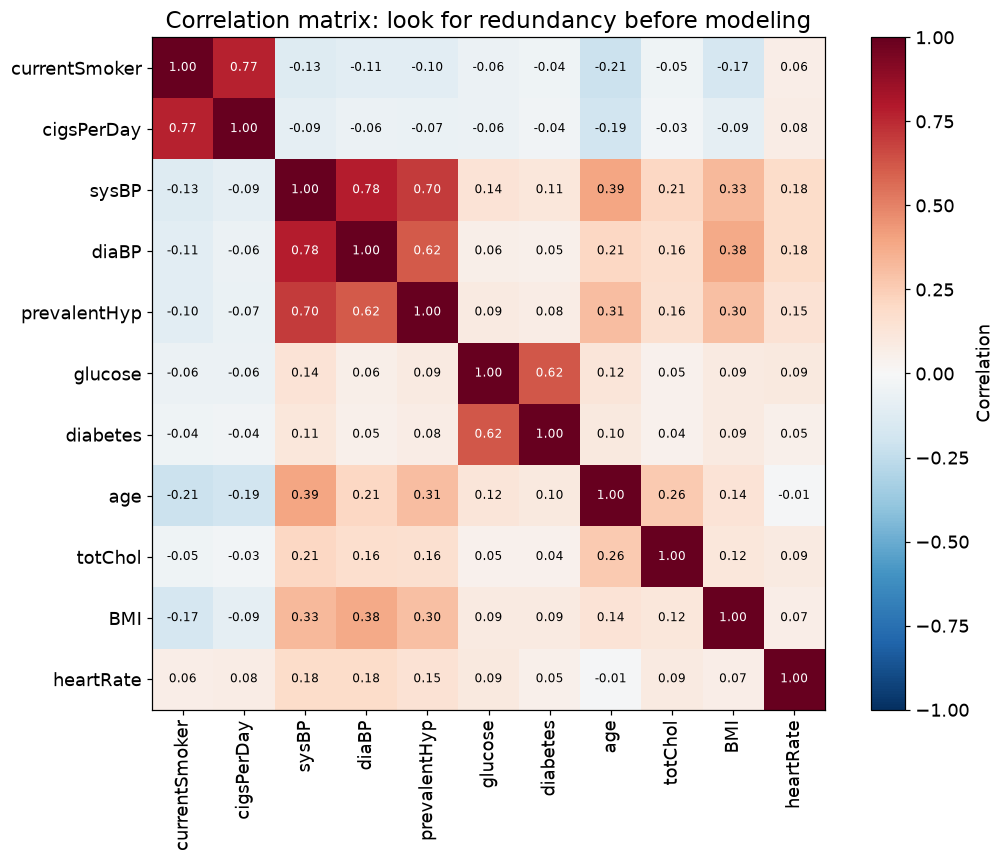

In [25]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8, color="white" if abs(corr.iloc[i, j]) > 0.6 else "black")

plt.colorbar(im, ax=ax, label="Correlation")
plt.title("Correlation matrix: look for redundancy before modeling")
plt.tight_layout()
plt.savefig(OUT/'chart_34.png', bbox_inches='tight'); plt.show()


## 10. Class imbalance

The observed CHD outcome is imbalanced, but the correct response depends on the analytical objective.

### For inferential logistic regression
Preserve the natural outcome distribution. Do **not** oversample cases merely to make the classes equal.

### For machine-learning prediction
Use stratified splitting first. If class imbalance harms clinically important detection, compare approaches such as:

- class weighting
- threshold tuning
- carefully designed resampling
- SMOTE or related methods inside training folds only

Never resample the complete dataset before train-test splitting because that can create information leakage.

Also remember that with an imbalanced outcome, accuracy alone is usually not an adequate performance metric.


In [26]:
class_summary = pd.DataFrame({
    "class": ["No 10-year CHD", "10-year CHD"],
    "n": [int((df_eda["TenYearCHD"] == 0).sum()),
          int((df_eda["TenYearCHD"] == 1).sum())],
})

class_summary["percent"] = 100 * class_summary["n"] / class_summary["n"].sum()
class_summary


,class,n,percent
0,No 10-year CHD,3596,84.811
1,10-year CHD,644,15.189


## 11. MODEL: EDA-informed multivariable logistic regression

Because `TenYearCHD` is binary, we use multivariable **logistic regression**.

The example specification intentionally avoids placing every correlated representation of the same construct into the model.

For example:

- `cigsPerDay` is used instead of simultaneously forcing both `currentSmoker` and `cigsPerDay` into the model.
- `sysBP` is used as the principal continuous BP measure rather than automatically including systolic BP, diastolic BP, and prevalent hypertension together.

This is a modeling decision informed by EDA, not an automatic universal rule.

For interpretability, some continuous variables are rescaled so odds ratios correspond to meaningful increments.


In [27]:
model_vars = [
    "TenYearCHD", "male", "age", "education", "cigsPerDay",
    "BPMeds", "prevalentStroke", "diabetes",
    "totChol", "sysBP", "BMI", "heartRate", "glucose"
]

model_df = df_eda[model_vars].dropna().copy()

print(f"Original N: {len(df_eda):,}")
print(f"Complete-case model N: {len(model_df):,}")
print(f"Excluded because at least one model variable was missing: {len(df_eda) - len(model_df):,}")
print()
print("For publication-grade inference, assess the missingness mechanism and consider")
print("multiple imputation rather than automatically relying on complete-case analysis.")


Original N: 4,240
Complete-case model N: 3,658
Excluded because at least one model variable was missing: 582

For publication-grade inference, assess the missingness mechanism and consider
multiple imputation rather than automatically relying on complete-case analysis.


The complete-case model excludes participants with any missing model input. Preserving the outcome distribution means avoiding artificial balancing; it does not guarantee that complete-case selection preserves the full cohort prevalence. Compare the model sample with the original cohort.

In [28]:
# Rescale continuous predictors for interpretable odds ratios
model_df["age_5y"] = model_df["age"] / 5
model_df["cigs_10"] = model_df["cigsPerDay"] / 10
model_df["sysBP_10"] = model_df["sysBP"] / 10
model_df["totChol_10"] = model_df["totChol"] / 10
model_df["BMI_5"] = model_df["BMI"] / 5
model_df["glucose_10"] = model_df["glucose"] / 10
model_df["heartRate_10"] = model_df["heartRate"] / 10

formula = '''
TenYearCHD ~ male + age_5y + cigs_10 + sysBP_10 +
             totChol_10 + BMI_5 + glucose_10 +
             BPMeds + prevalentStroke + diabetes +
             heartRate_10 + C(education)
'''

fit = smf.logit(formula, data=model_df).fit(disp=False)
fit.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             TenYearCHD   No. Observations:                 3658
Model:                          Logit   Df Residuals:                     3643
Method:                           MLE   Df Model:                           14
Date:                Wed, 07 Oct 2026   Pseudo R-squ.:                  0.1172
Time:                        00:36:17   Log-Likelihood:                -1377.7
converged:                       True   LL-Null:                       -1560.6
Covariance Type:            nonrobust   LLR p-value:                 1.996e-69
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -8.7569      0.627    -13.968      0.000      -9.986      -7.528
C(education)[T.2.0]    -0.1908      0.123     -1.548      0.122      -0.432       0.051
C(education)[T.3.0]    -0.2008      0.150     -1.340      0.180      -0.494       0.093
C(education)[T.4.0]    -0.0591      0.164     -0.360      0.719      -0.381       0.263
male                    0.5327      0.109      4.892      0.000       0.319       0.746
age_5y                  0.3167      0.033      9.602      0.000       0.252       0.381
cigs_10                 0.2006      0.042      4.744      0.000       0.118       0.284
sysBP_10                0.1677      0.024      7.134      0.000       0.122       0.214
totChol_10              0.0239      0.011      2.116      0.034       0.002       0.046
BMI_5                   0.0242      0.062      0.390      0.697      -0.098       0.146
glucose_10              0.0717      0.022      3.201      0.001       0.028       0.116
BPMeds                  0.2008      0.235      0.853      0.394      -0.260       0.662
prevalentStroke         0.7224      0.490      1.474      0.140      -0.238       1.683
diabetes                0.0353      0.317      0.111      0.911      -0.586       0.656
heartRate_10           -0.0268      0.042     -0.637      0.524      -0.109       0.056
=======================================================================================
"""

In [29]:
# Convert coefficients to adjusted odds ratios
params = fit.params
ci = fit.conf_int()

results = pd.DataFrame({
    "Adjusted_OR": np.exp(params),
    "CI_2.5%": np.exp(ci[0]),
    "CI_97.5%": np.exp(ci[1]),
    "p_value": fit.pvalues
})

results = results.drop(index="Intercept")
results.round(3)


,Adjusted_OR,CI_2.5%,CI_97.5%,p_value
C(education)[T.2.0],0.826,0.649,1.052,0.122
C(education)[T.3.0],0.818,0.610,1.097,0.180
C(education)[T.4.0],0.943,0.683,1.300,0.719
male,1.704,1.376,2.109,0.000
age_5y,1.373,1.287,1.464,0.000
cigs_10,1.222,1.125,1.328,0.000
sysBP_10,1.183,1.129,1.238,0.000
totChol_10,1.024,1.002,1.047,0.034
BMI_5,1.024,0.907,1.157,0.697
glucose_10,1.074,1.028,1.123,0.001


### Interpretation guide

Examples:

- An adjusted odds ratio above 1 means higher odds of 10-year CHD as the predictor increases, holding the other included variables constant.
- An adjusted odds ratio below 1 means lower odds, holding the other included variables constant.
- Confidence intervals communicate uncertainty.
- Statistical association is not equivalent to causal effect.

Scaling matters. For example, `age_5y` corresponds to a **5-year age increase**, while `sysBP_10` corresponds to a **10 mmHg systolic BP increase**.


In [30]:
# Print selected interpretable results
selected = {
    "male": "Male vs female-coded reference",
    "age_5y": "Per 5-year increase in age",
    "cigs_10": "Per 10 cigarettes/day",
    "sysBP_10": "Per 10 mmHg systolic BP",
    "totChol_10": "Per 10-unit total cholesterol",
    "glucose_10": "Per 10-unit glucose"
}

for term, label in selected.items():
    row = results.loc[term]
    print(
        f"{label}: OR {row['Adjusted_OR']:.2f} "
        f"(95% CI {row['CI_2.5%']:.2f} to {row['CI_97.5%']:.2f})"
    )


Male vs female-coded reference: OR 1.70 (95% CI 1.38 to 2.11)
Per 5-year increase in age: OR 1.37 (95% CI 1.29 to 1.46)
Per 10 cigarettes/day: OR 1.22 (95% CI 1.12 to 1.33)
Per 10 mmHg systolic BP: OR 1.18 (95% CI 1.13 to 1.24)
Per 10-unit total cholesterol: OR 1.02 (95% CI 1.00 to 1.05)
Per 10-unit glucose: OR 1.07 (95% CI 1.03 to 1.12)


## 12. Model performance, without confusing prediction with inference

Although this lesson's model is primarily used for adjusted association, we can still inspect how its fitted probabilities behave.

Because the outcome is imbalanced, report several metrics rather than accuracy alone.

These metrics reuse the fitting sample and describe apparent performance. They are not held-out estimates of predictive performance.


In [31]:
pred_prob = fit.predict(model_df)

roc_auc = roc_auc_score(model_df["TenYearCHD"], pred_prob)
pr_auc = average_precision_score(model_df["TenYearCHD"], pred_prob)
brier = brier_score_loss(model_df["TenYearCHD"], pred_prob)

print(f"ROC-AUC: {roc_auc:.3f}")
print(f"Average precision: {pr_auc:.3f}")
print(f"Brier score: {brier:.3f}")


ROC-AUC: 0.739
Average precision: 0.363
Brier score: 0.115


In [32]:
# Simple calibration-by-decile table
calibration = pd.DataFrame({
    "observed": model_df["TenYearCHD"].values,
    "predicted": pred_prob.values
})

calibration["risk_decile"] = pd.qcut(
    calibration["predicted"],
    10,
    duplicates="drop"
)

cal_table = (
    calibration.groupby("risk_decile", observed=True)
    .agg(
        n=("observed", "size"),
        mean_predicted=("predicted", "mean"),
        observed_rate=("observed", "mean")
    )
    .reset_index(drop=True)
)

cal_table


,n,mean_predicted,observed_rate
0,366,0.030,0.025
1,366,0.047,0.060
2,366,0.065,0.063
3,365,0.084,0.066
4,366,0.106,0.117
5,366,0.132,0.115
6,365,0.163,0.167
7,366,0.203,0.227
8,366,0.269,0.295
9,366,0.424,0.388


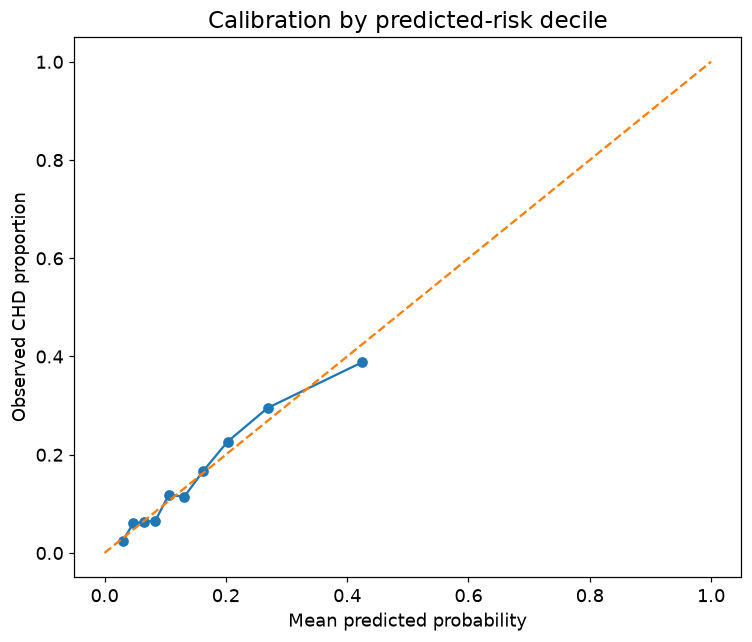

In [33]:
plt.figure(figsize=(7, 6))
plt.plot(cal_table["mean_predicted"], cal_table["observed_rate"], marker="o")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed CHD proportion")
plt.title("Calibration by predicted-risk decile")
plt.tight_layout()
plt.savefig(OUT/'chart_46.png', bbox_inches='tight'); plt.show()


## 13. Optional predictive extension

If the objective changes from **inference** to **machine-learning prediction**, class imbalance should be addressed inside a proper validation workflow.

Recommended sequence:

**Stratified split → preprocessing within training data → class weighting or resampling if needed → threshold selection → locked test evaluation**

Compare:

- ROC-AUC
- PR-AUC
- sensitivity
- specificity
- positive and negative predictive values
- calibration
- Brier score
- clinical utility at relevant thresholds

Do not choose a balancing technique simply because the classes are unequal.


## 14. EXPLAIN: what did EDA teach us?

A good EDA should change how you think about the model.

In this dataset, EDA can reveal:

- the outcome is imbalanced;
- missingness is concentrated in particular variables, especially glucose;
- extreme clinical values require investigation, not automatic deletion;
- several predictors contain overlapping information;
- crude relationships can change after multivariable adjustment;
- meaningful scaling makes regression results easier to interpret;
- the modeling strategy should follow the scientific objective.

### Final takeaway

> **EDA is where data stops being a spreadsheet and starts becoming evidence.**

Sometimes the observation you are tempted to delete is the beginning of the research question that matters most.


## Reproducibility checklist

Before sharing or publishing an analysis:

- document the dataset version and provenance;
- preserve the raw file unchanged;
- record all preprocessing decisions;
- justify missing-data treatment;
- distinguish flagged outliers from confirmed errors;
- document engineered variables;
- report both crude and adjusted findings where relevant;
- avoid data leakage;
- report uncertainty;
- distinguish association, prediction, and causation;
- preserve code and software versions.

**EvidenceLab | Dr. Amobi Andrew Onovo**


## Experiment: change the prediction threshold
Keep the fitted model and fitting sample fixed. Change only the decision threshold. Observe how sensitivity, specificity and positive predictive value move. This is a teaching sensitivity analysis, not a validated threshold recommendation. Prediction work must select thresholds inside training/validation data and evaluate once on a locked test set.


 threshold  sensitivity  specificity   PPV
     0.100        0.842        0.472 0.223
     0.150        0.697        0.666 0.272
     0.200        0.537        0.797 0.323
     0.300        0.287        0.918 0.386
     0.500        0.086        0.992 0.667


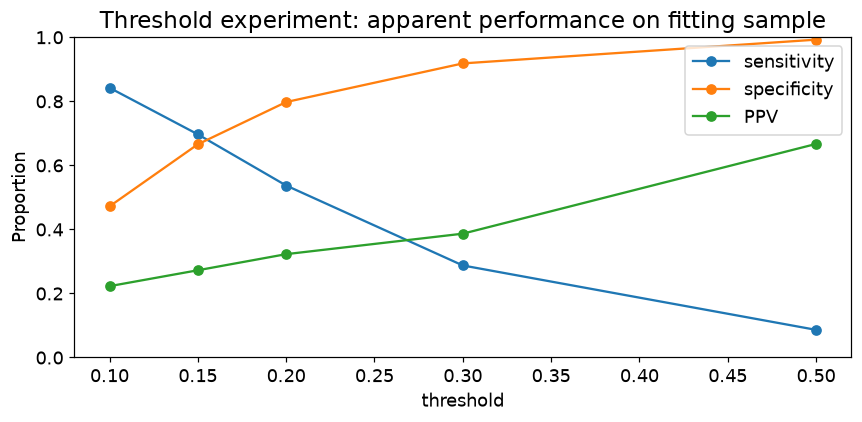

In [34]:
threshold_rows = []
for threshold in [0.10, 0.15, 0.20, 0.30, 0.50]:
    tn, fp, fn, tp = confusion_matrix(model_df['TenYearCHD'], pred_prob >= threshold).ravel()
    threshold_rows.append({'threshold':threshold, 'sensitivity':tp/(tp+fn), 'specificity':tn/(tn+fp), 'PPV':tp/(tp+fp) if tp+fp else np.nan})
threshold_table = pd.DataFrame(threshold_rows)
print(threshold_table.to_string(index=False))
threshold_table.plot(x='threshold', y=['sensitivity','specificity','PPV'], marker='o', ylim=(0,1), figsize=(8,4))
plt.ylabel('Proportion'); plt.title('Threshold experiment: apparent performance on fitting sample')
plt.tight_layout(); plt.savefig(OUT/'threshold_experiment.png'); plt.show()


Lower thresholds flag more people and usually increase sensitivity while reducing specificity. The trade-off depends on the decision and the population. EDA helps expose it; external validation must test it.

## Export the evidence
The tables below preserve the audit and model results used in the lesson. Pair each adjusted odds ratio with its confidence interval, variable increment and complete-case population.


In [35]:
audit.to_csv(OUT/'audit.csv')
outcome_summary.to_csv(OUT/'outcome_summary.csv')
outlier_summary.to_csv(OUT/'outlier_summary.csv', index=False)
corr.to_csv(OUT/'correlations.csv')
results.to_csv(OUT/'adjusted_odds_ratios.csv')
cal_table.to_csv(OUT/'apparent_calibration.csv', index=False)
threshold_table.to_csv(OUT/'threshold_experiment.csv', index=False)
claims = {'rows':len(df), 'variables':df.shape[1], 'CHD_n':int(df.TenYearCHD.sum()), 'CHD_pct':float(100*df.TenYearCHD.mean()), 'glucose_missing_n':int(df.glucose.isna().sum()), 'glucose_missing_pct':float(100*df.glucose.isna().mean()), 'model_n':len(model_df), 'model_CHD_pct':float(100*model_df.TenYearCHD.mean()), 'dataset_sha256':DATA_SHA}
(OUT/'numerical_claims.json').write_text(json.dumps(claims, indent=2))
print(json.dumps(claims, indent=2))


{
  "rows": 4240,
  "variables": 16,
  "CHD_n": 644,
  "CHD_pct": 15.188679245283017,
  "glucose_missing_n": 388,
  "glucose_missing_pct": 9.150943396226415,
  "model_n": 3658,
  "model_CHD_pct": 15.226899945325314,
  "dataset_sha256": "412c9ea5f0dfb7ad243dfcd1f2b4df500101904a8f443a22f3080394391853e9"
}


## Investigate before you delete
1. Start with a scientific question and identify variable types.
2. Audit missingness and unusual values; investigate their context.
3. Engineer features that clarify meaning while preserving original values.
4. Use distributions and relationships to guide model specification.
5. Let inference or prediction determine validation and imbalance handling.

**Try it:** Explain what a complete-case analysis assumes. Compare two correlated predictors before putting them in one model. Change a threshold and describe who is missed or flagged.

The personal story supplied by Dr. Onovo begins with a 2010 ANC/PMTCT review; the linked publication reports a separate 2013 evaluation and was published in 2015. These dates refer to different stages of the research journey. The author's reported 40-citation milestone is not a bibliometric count verified here.

[Onovo and colleagues, BMC Public Health (2015), PMID 26310673](https://pubmed.ncbi.nlm.nih.gov/26310673/)

**What unexpected pattern made you question your analysis?**

EvidenceLab | Dr. Amobi Andrew Onovo | See it. Understand it. Run it.
